beep.wav


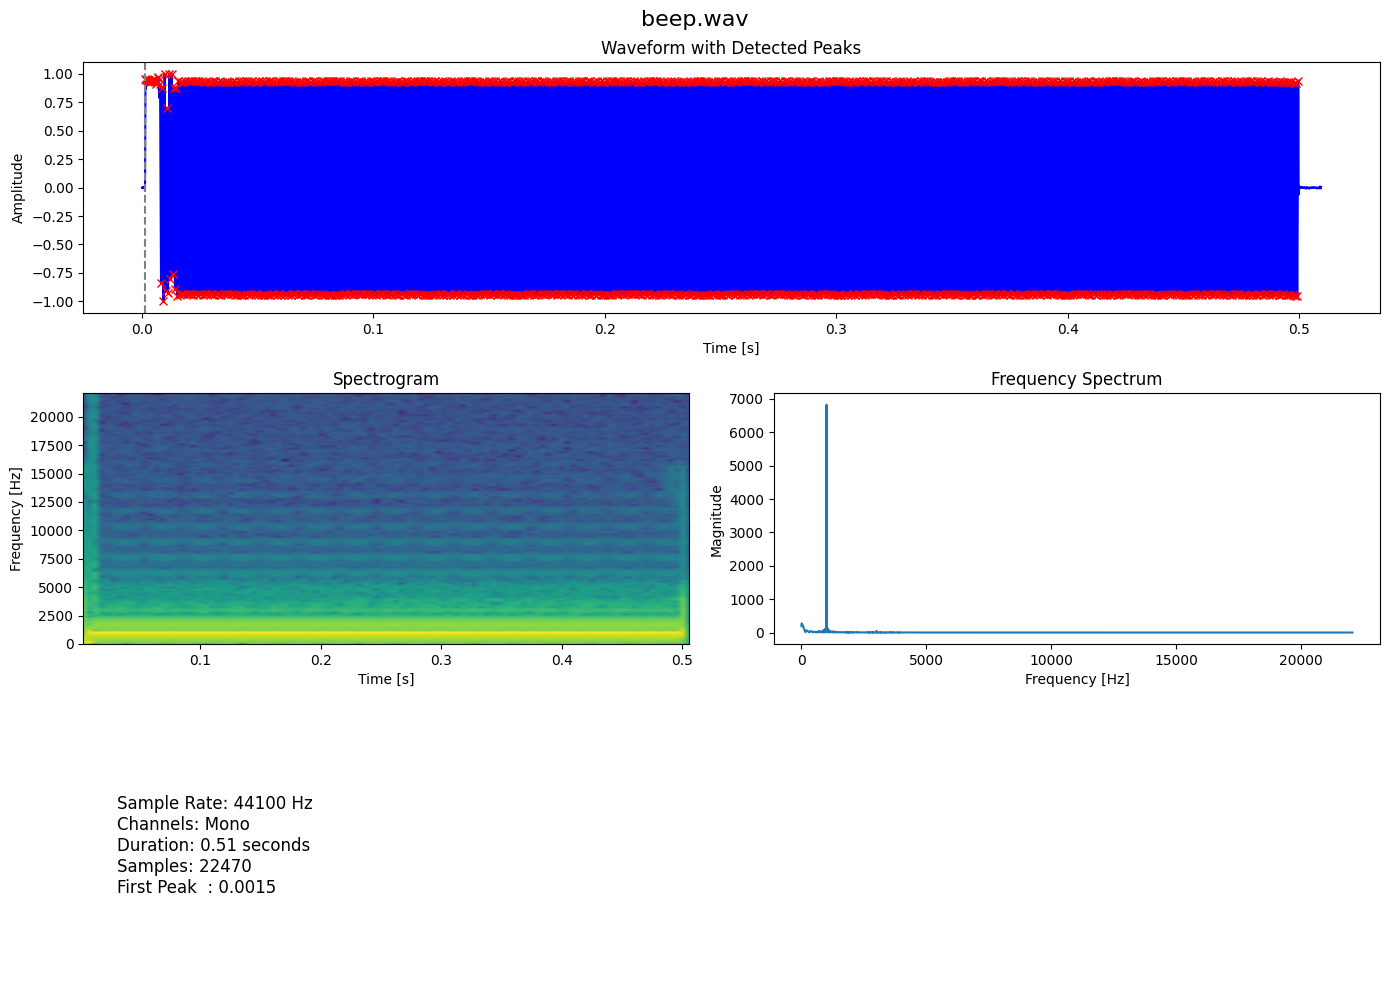

control_tone.wav


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_35308\3700196546.py:66: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')


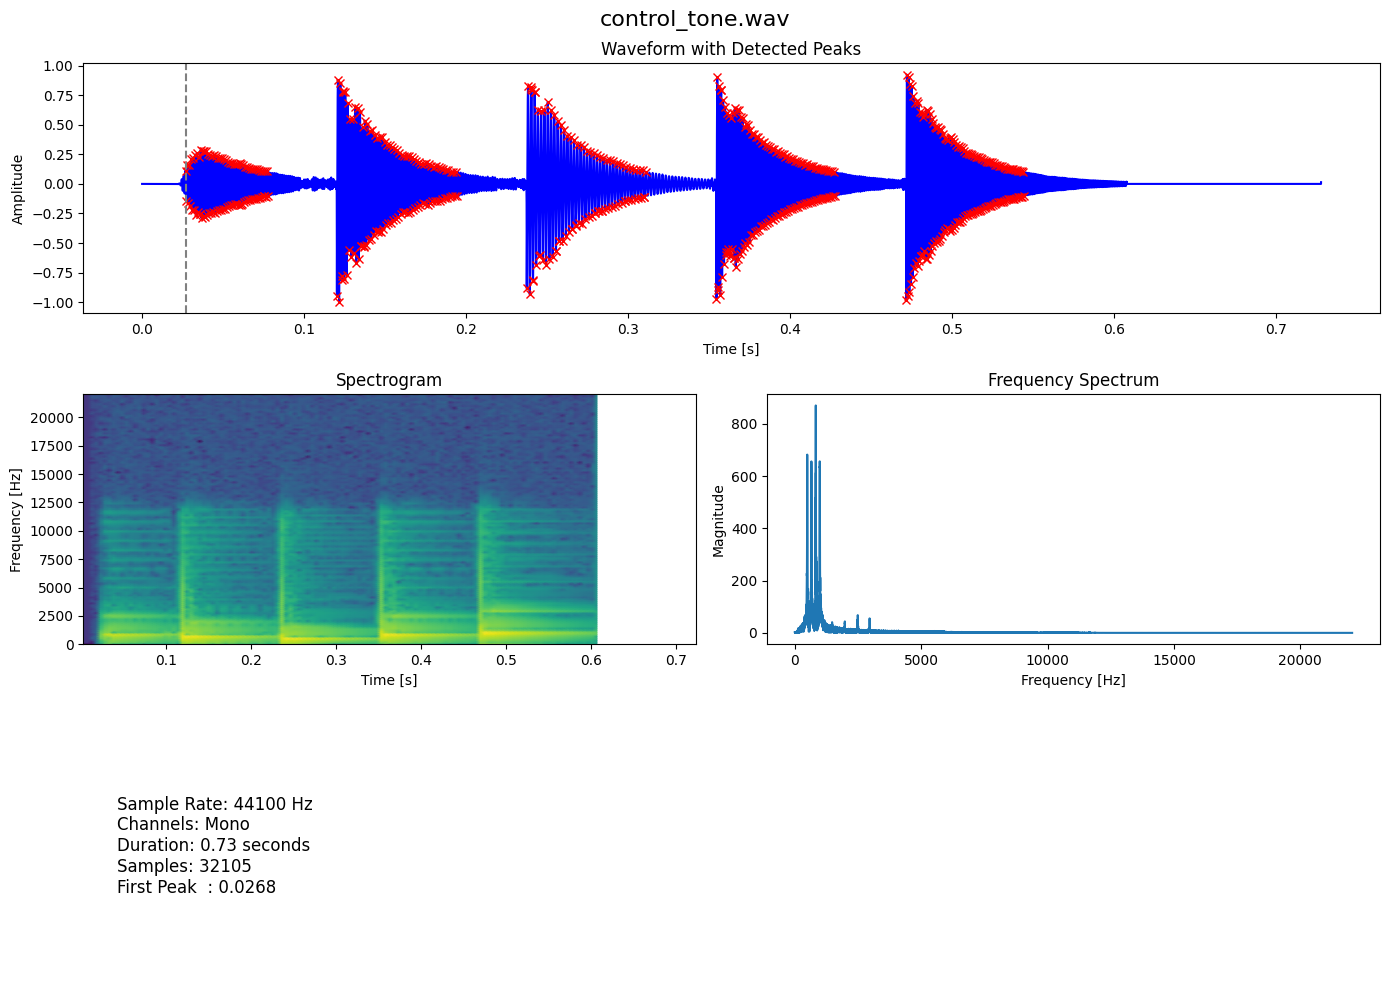

SD012_SD016_SD036_SD038_SD051_SD67_Whoop_doop.wav


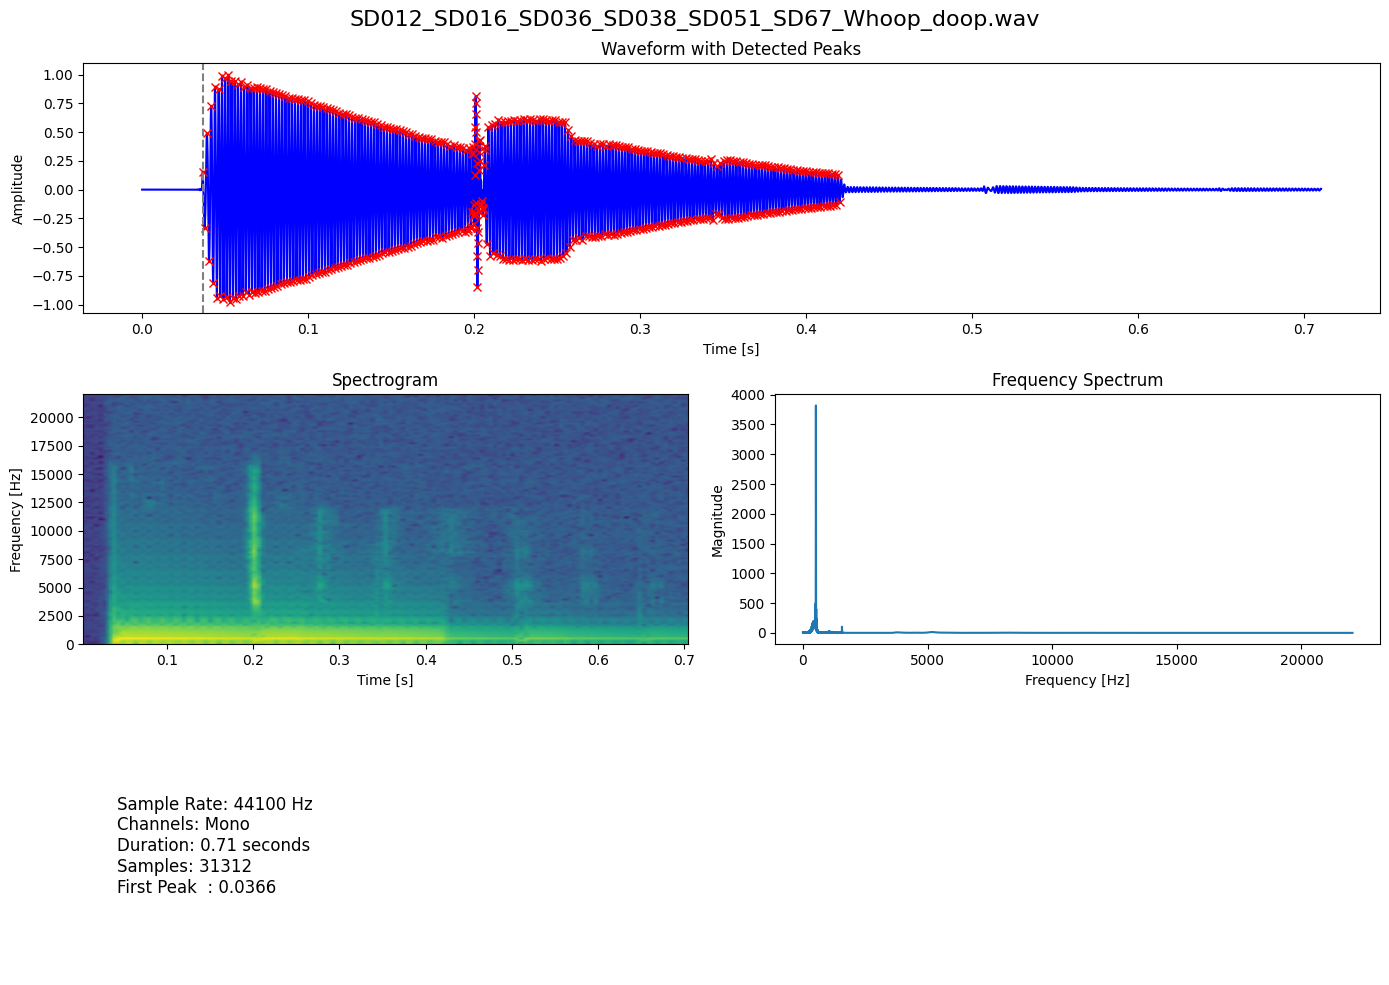

SD014_SD032_SD044_SD055_MI_droplets.wav


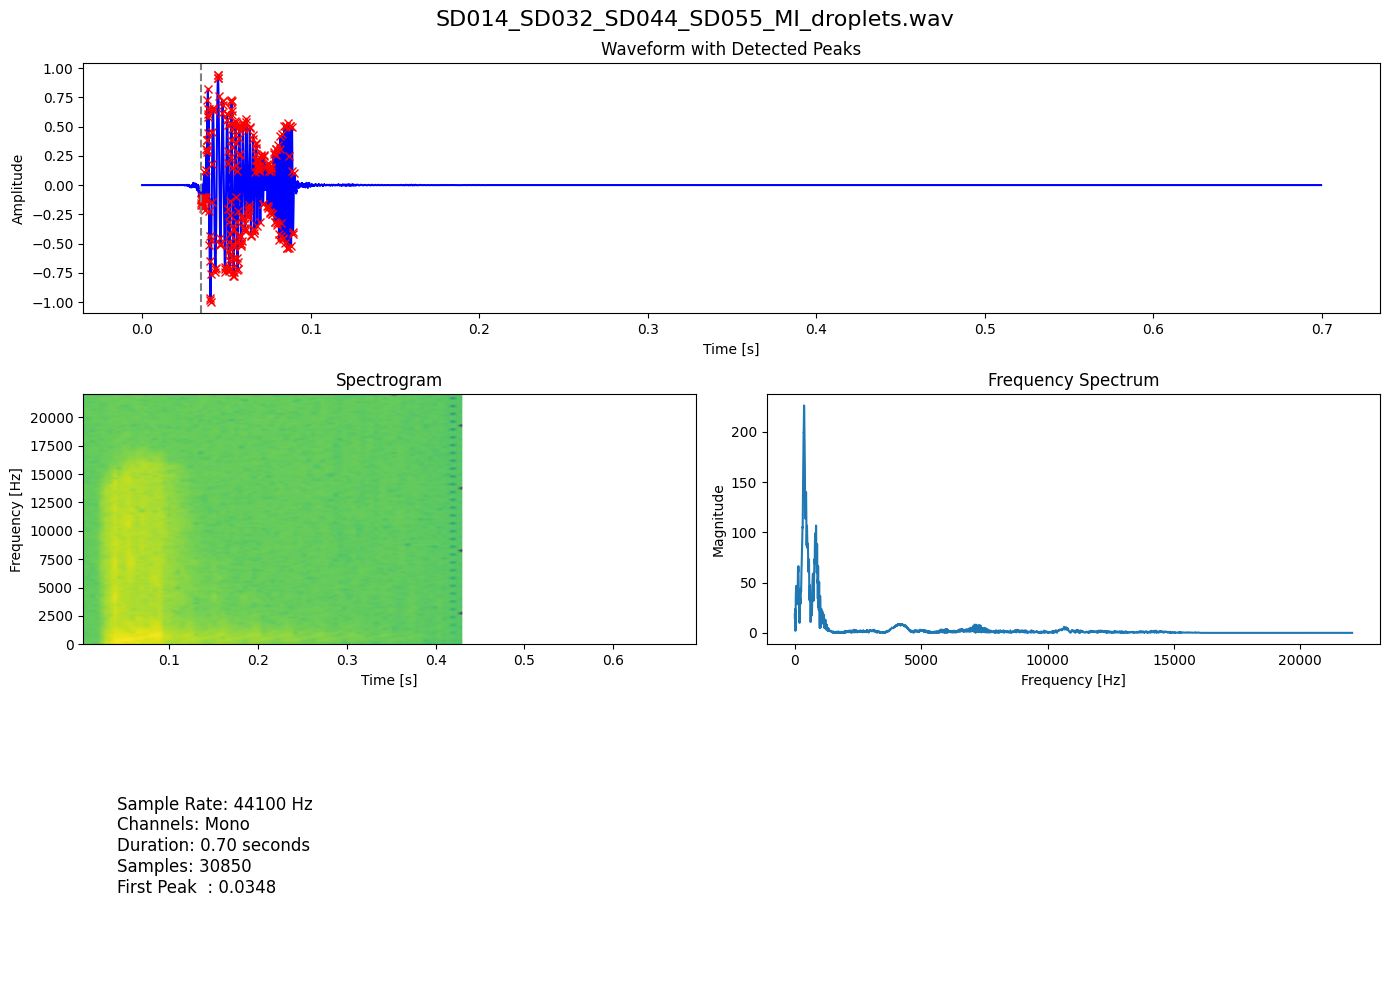

SD015_SD022_SD023_SD041_Realme_fun.wav


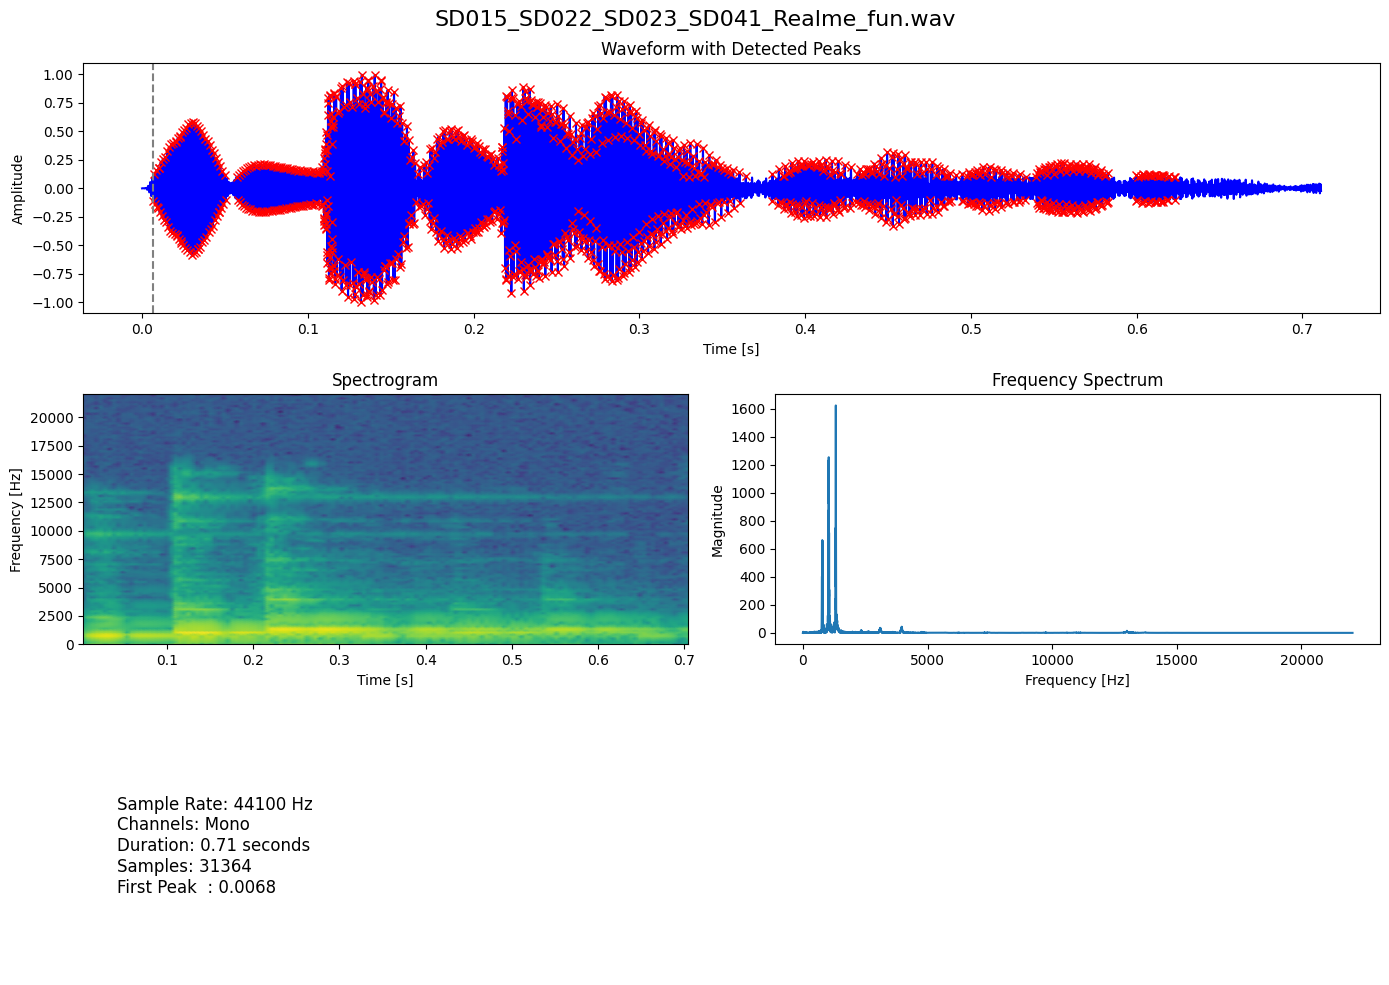

SD019_SD028_SD031_SD035_SD043_SD045_SD052_SD065_ipone_note.wav


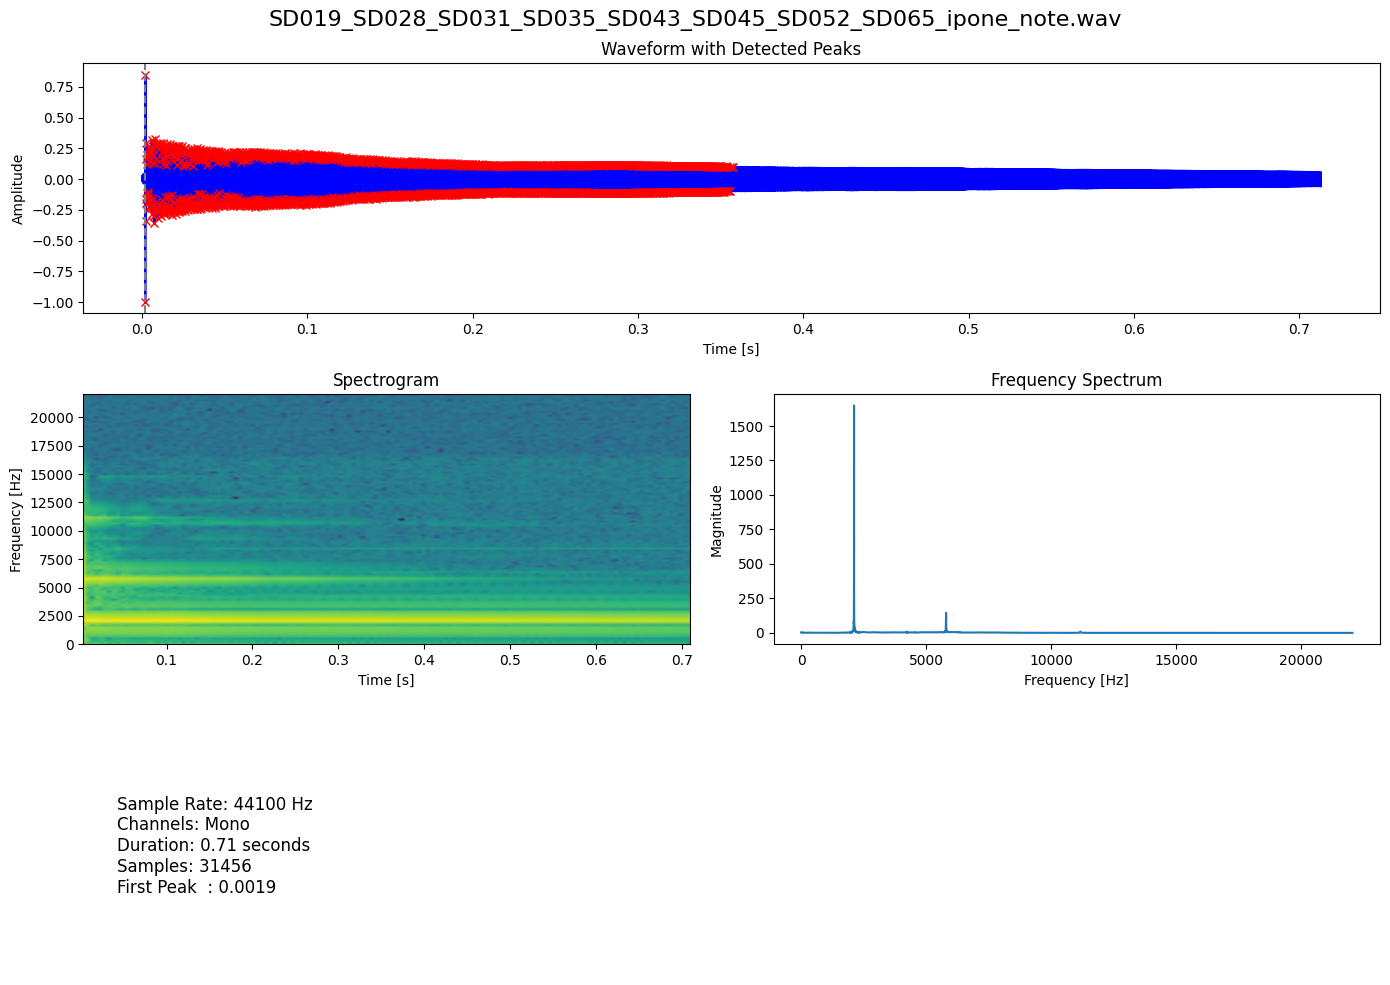

SD020_SD027_SD033_oneplustune.wav


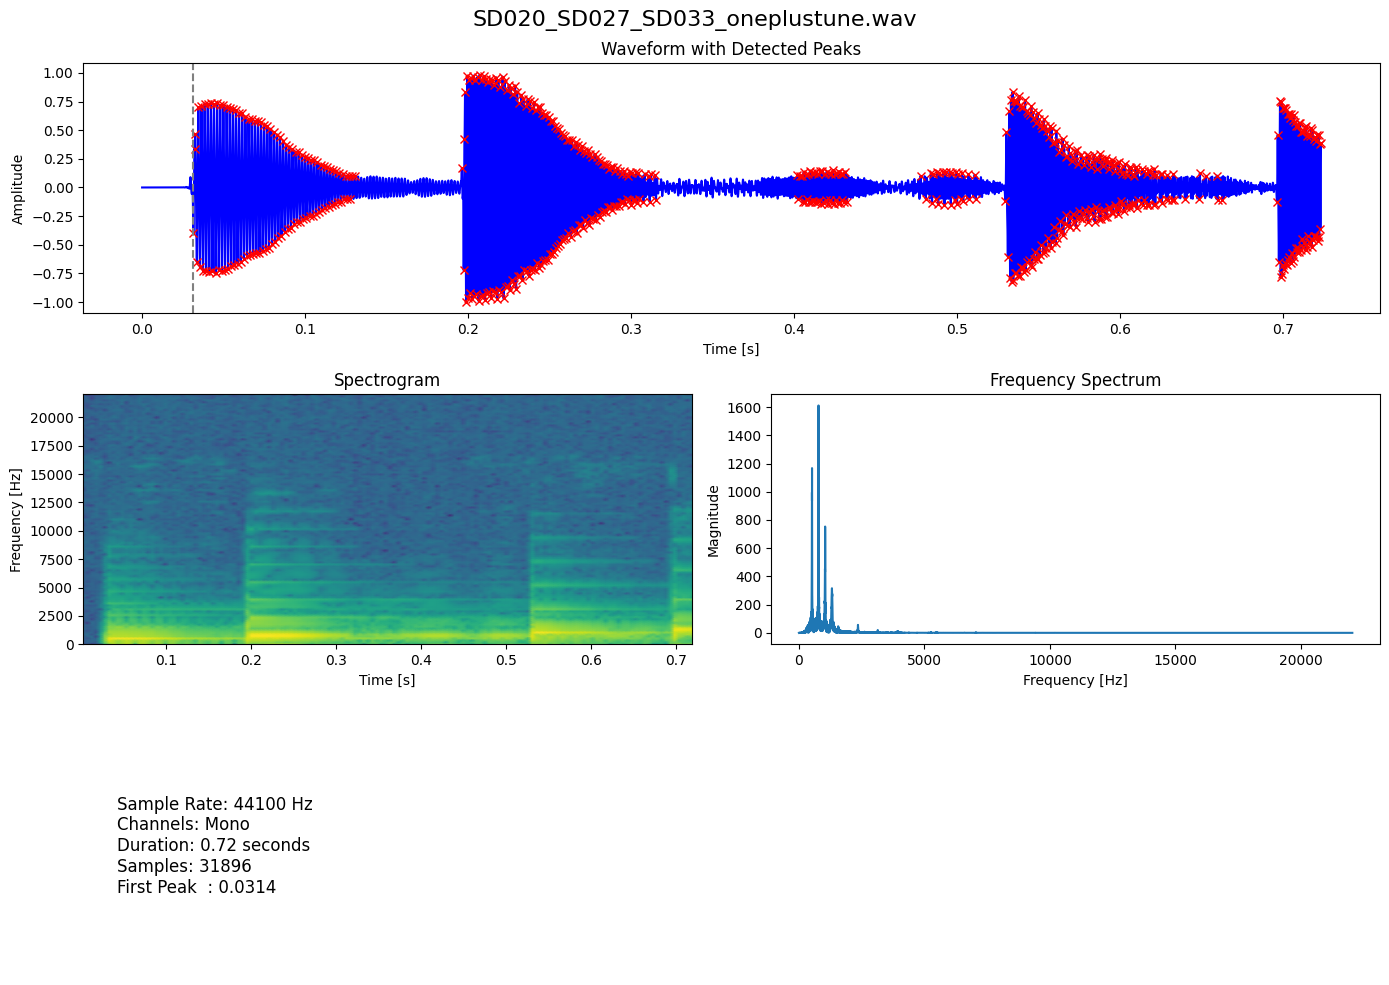

SD021_voyar.wav


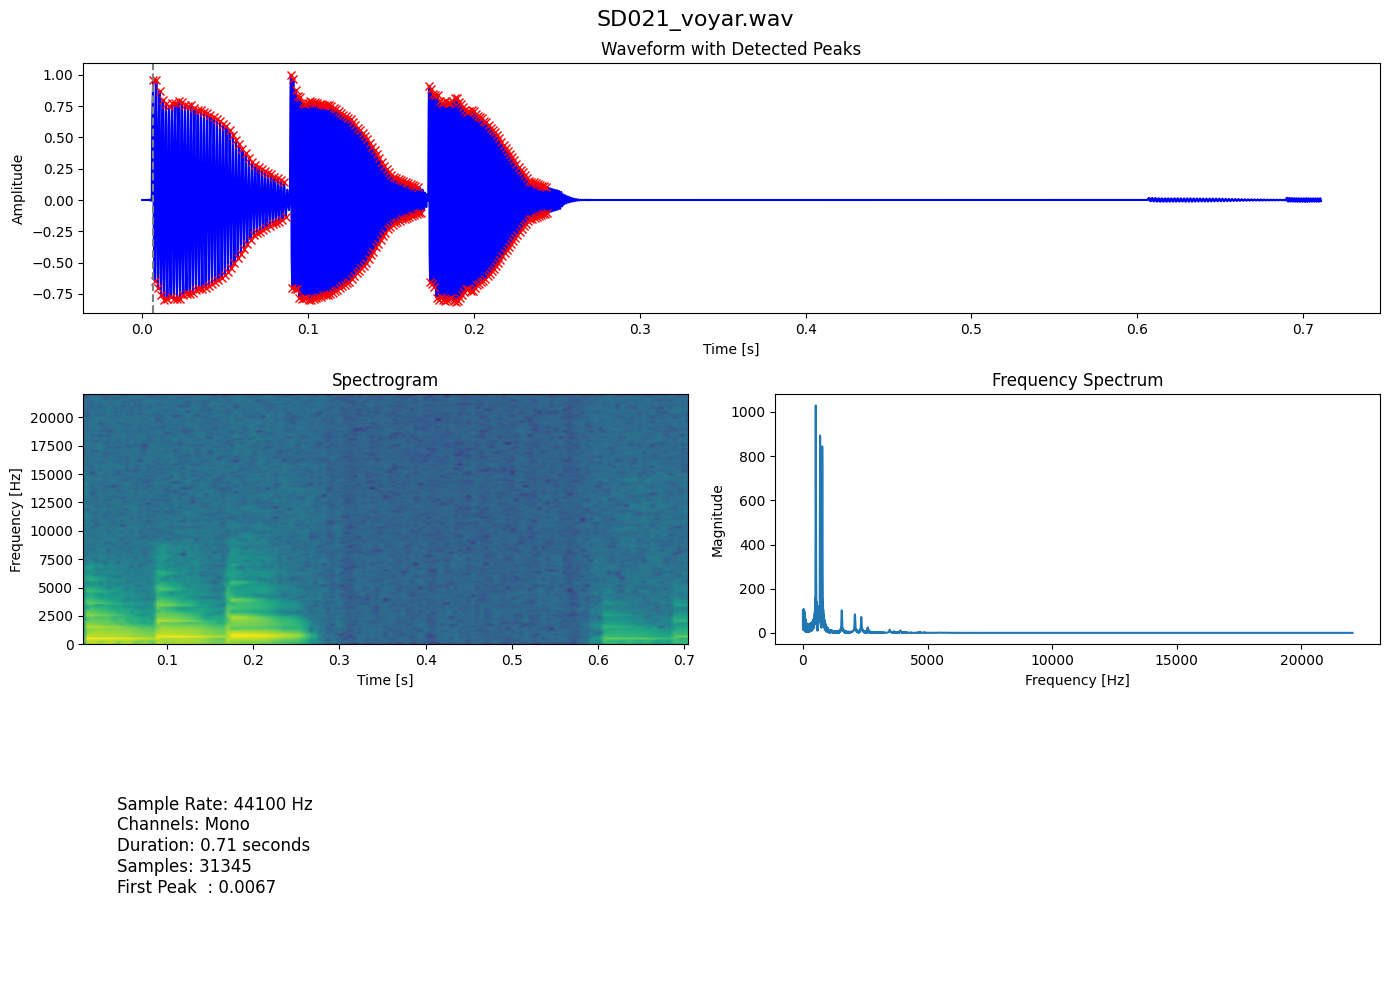

SD024_SD049_oneplus_meet.wav


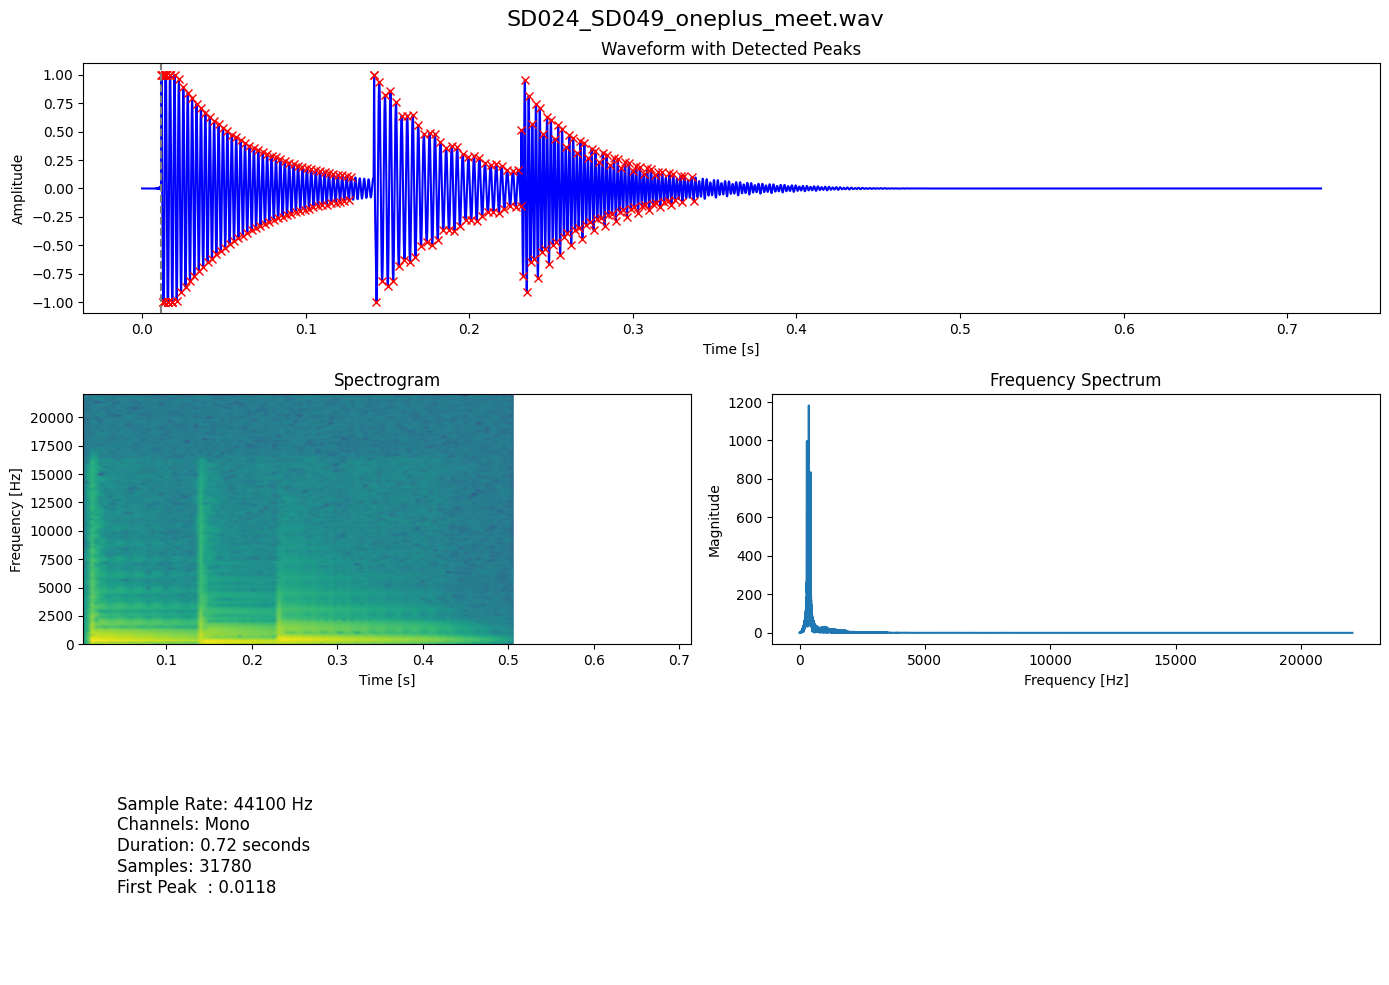

SD025_oneplus_blissful.wav


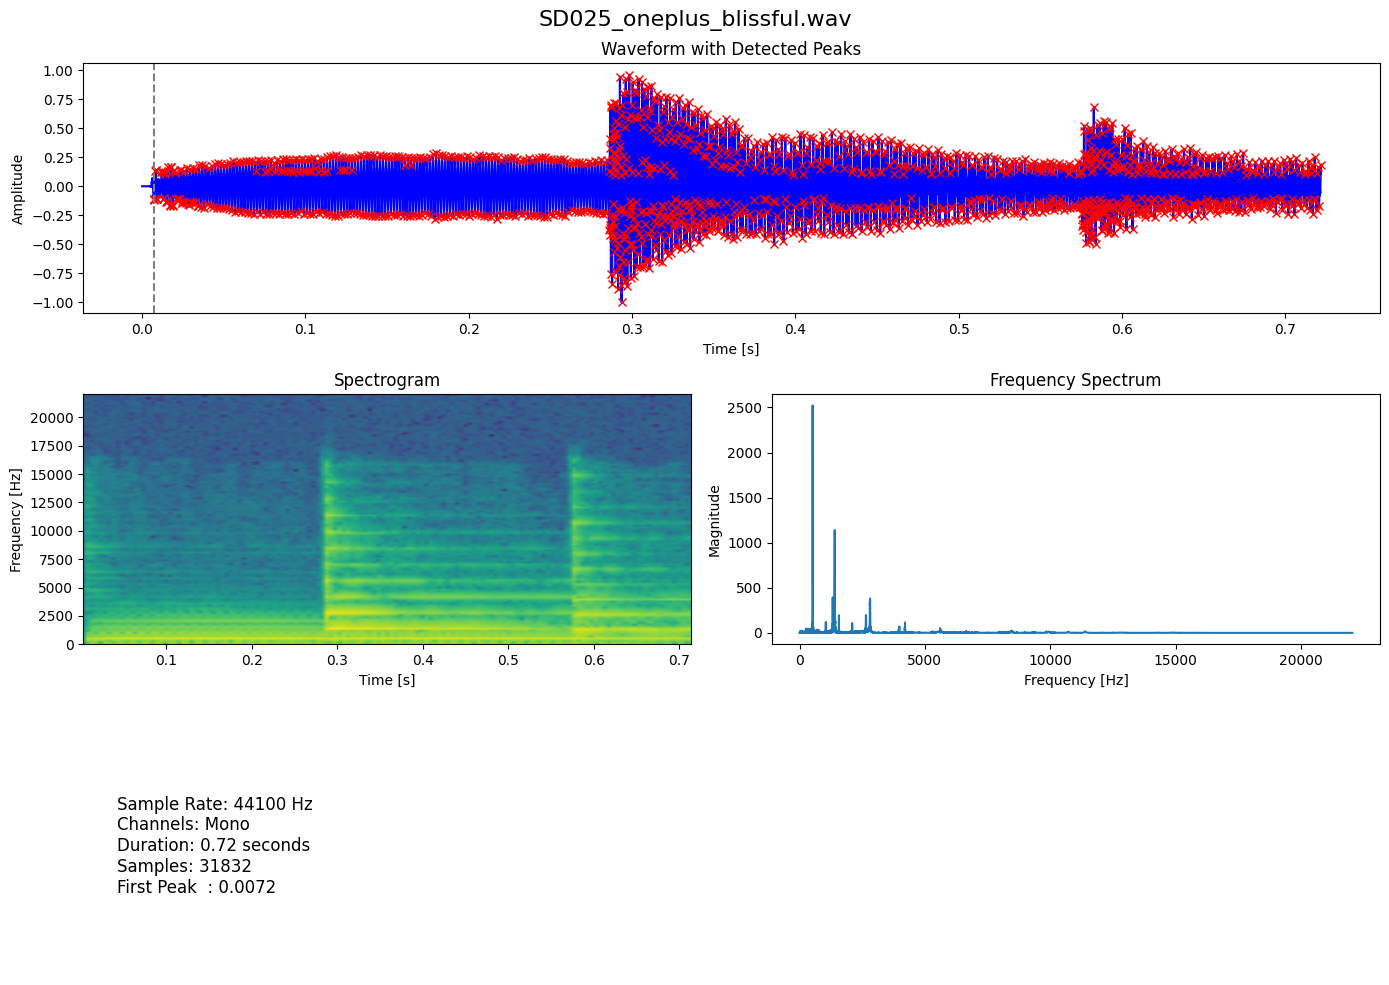

SD029_realme.wav


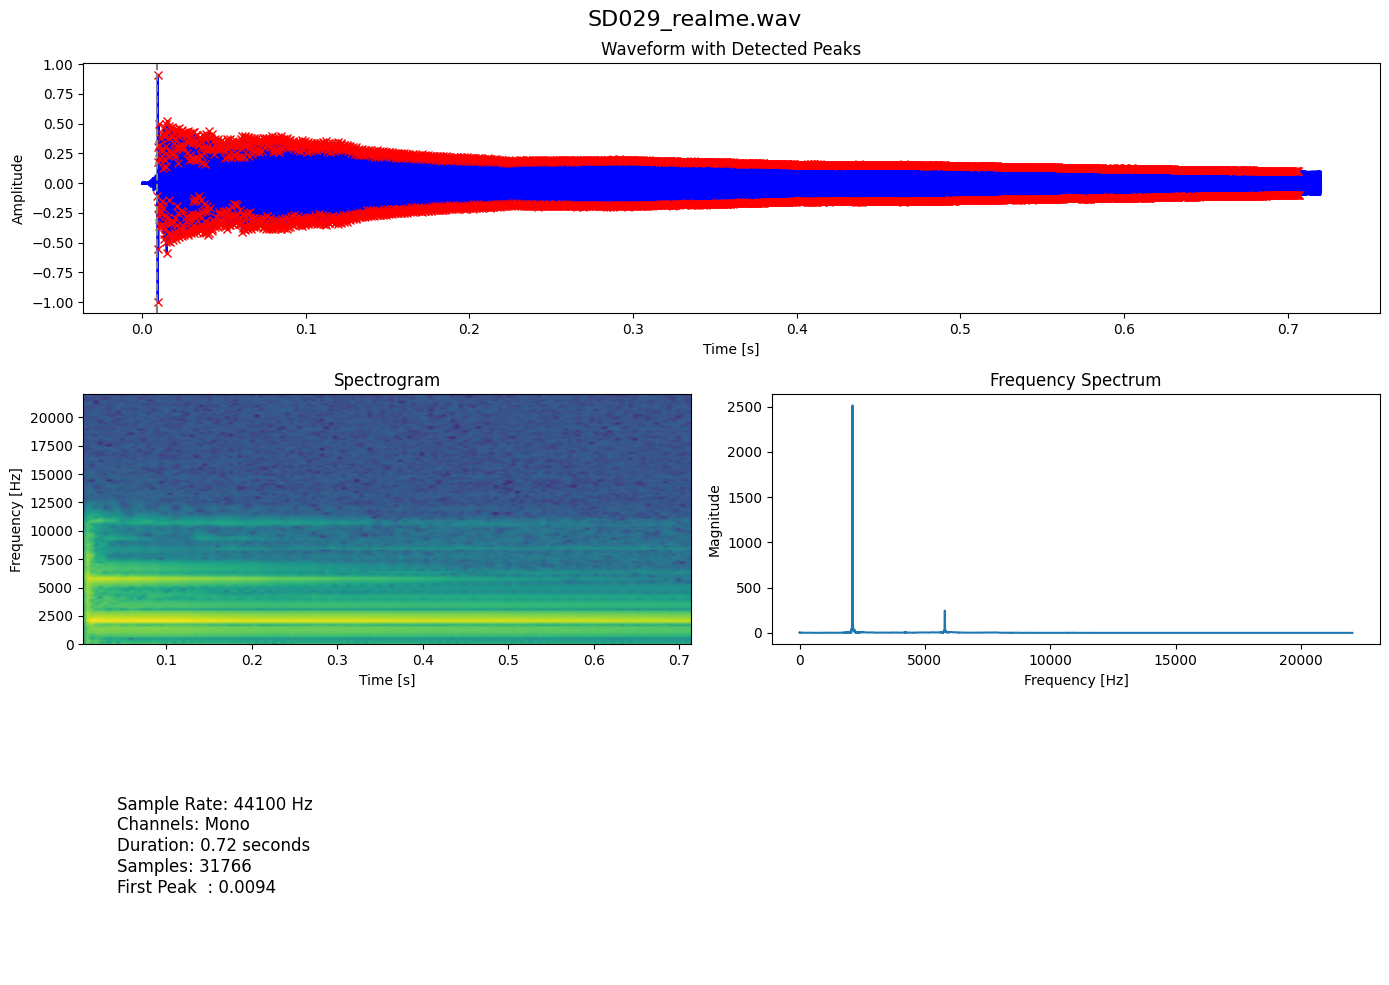

SD030_SD042_encounter_vivo.wav


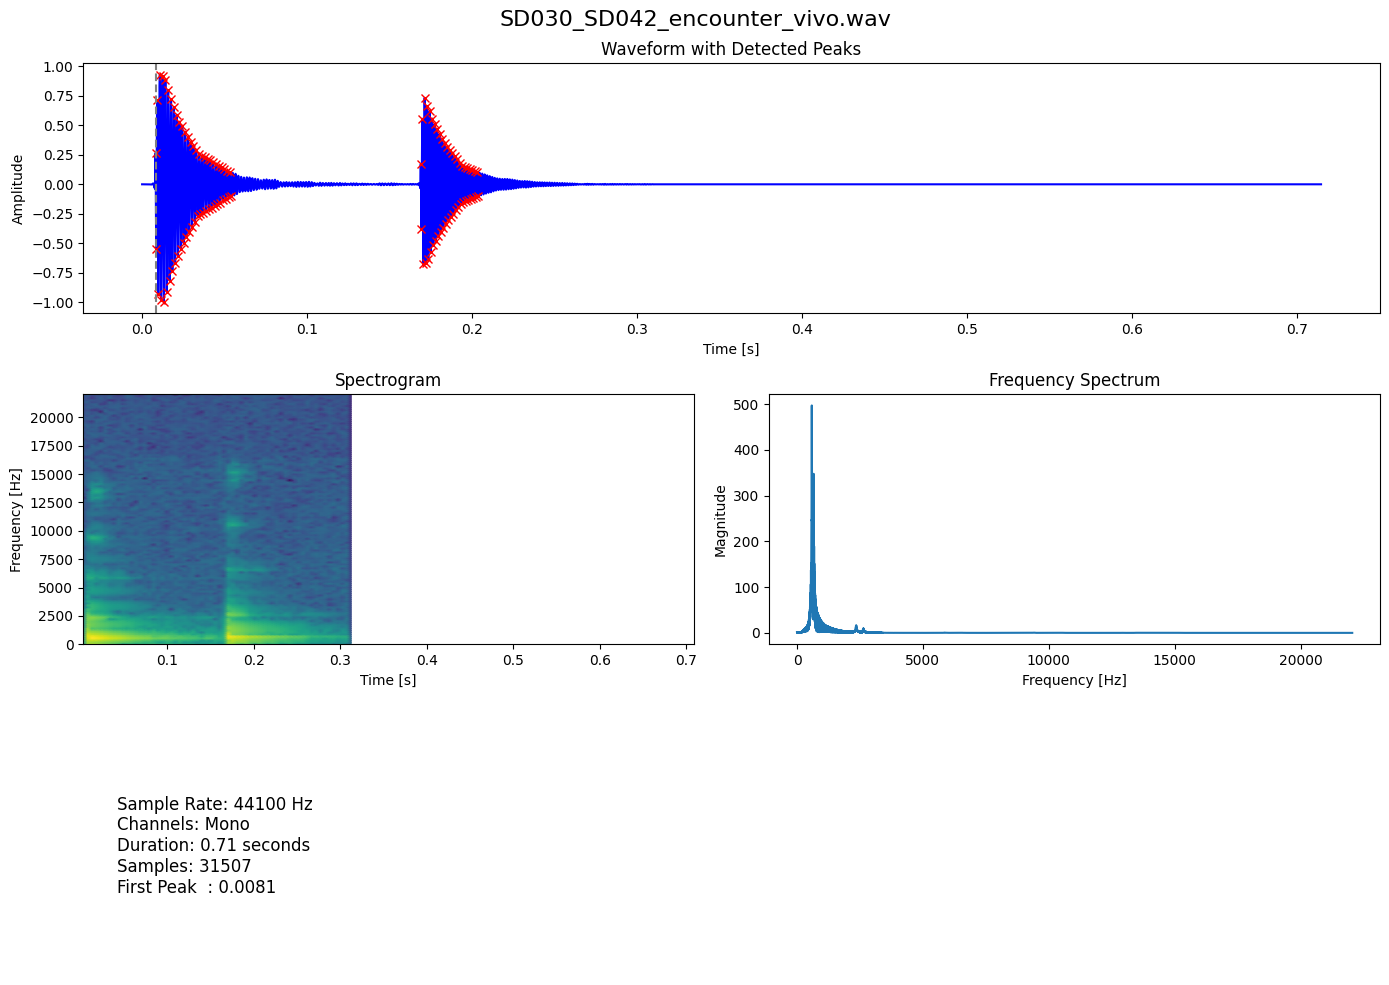

SD034_SD050_SD059_vibration.wav


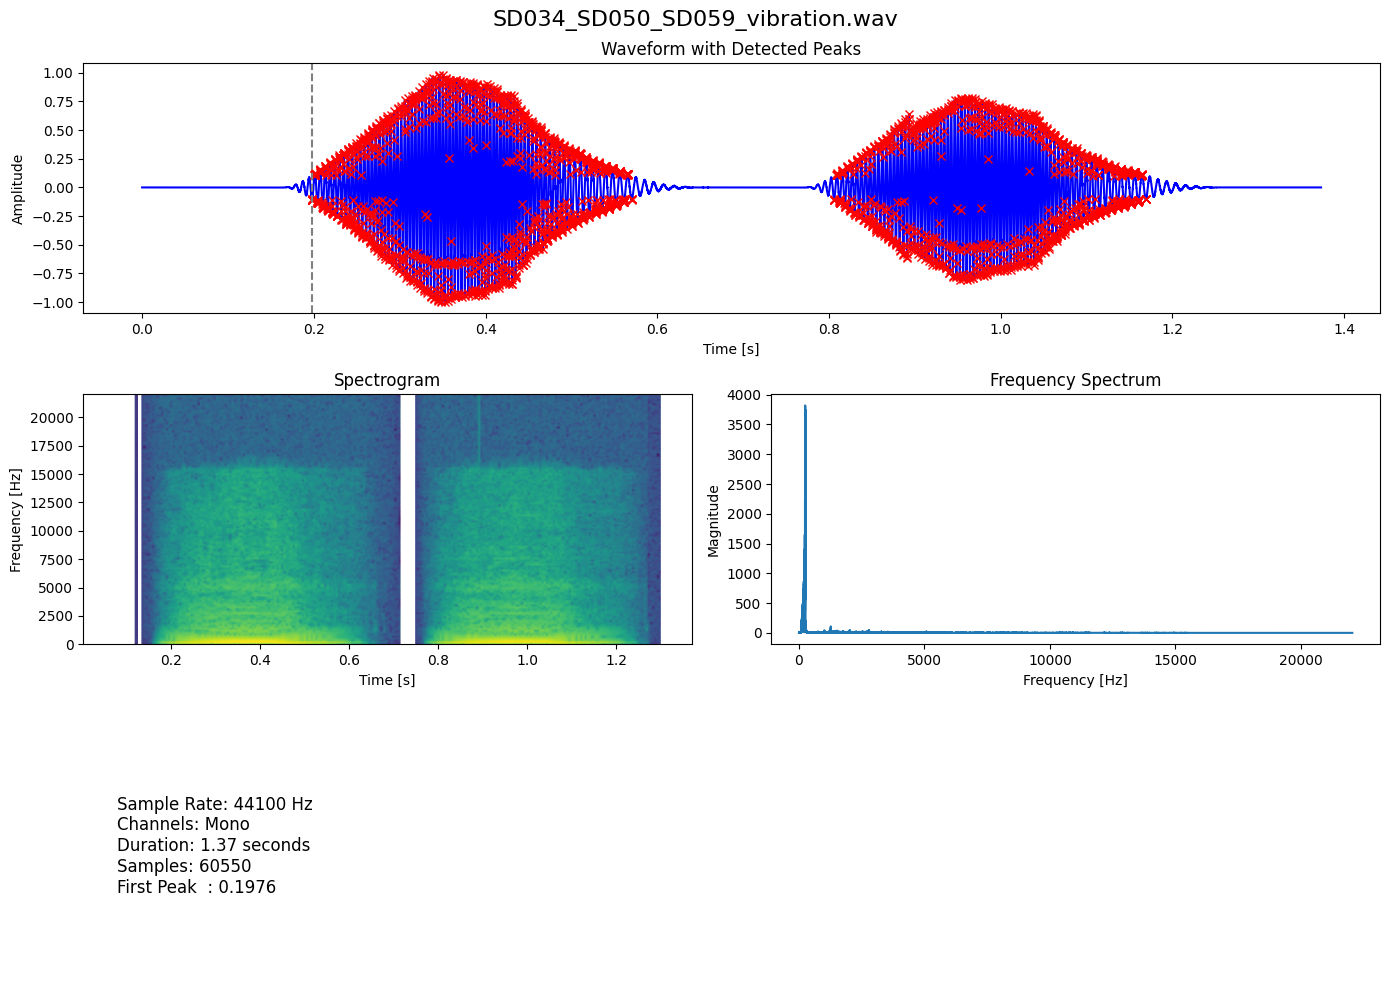

SD037_SD053_SD062_oppo.wav
SD037_SD053_SD062_oppo.wav has header error, using pydub to fix it...


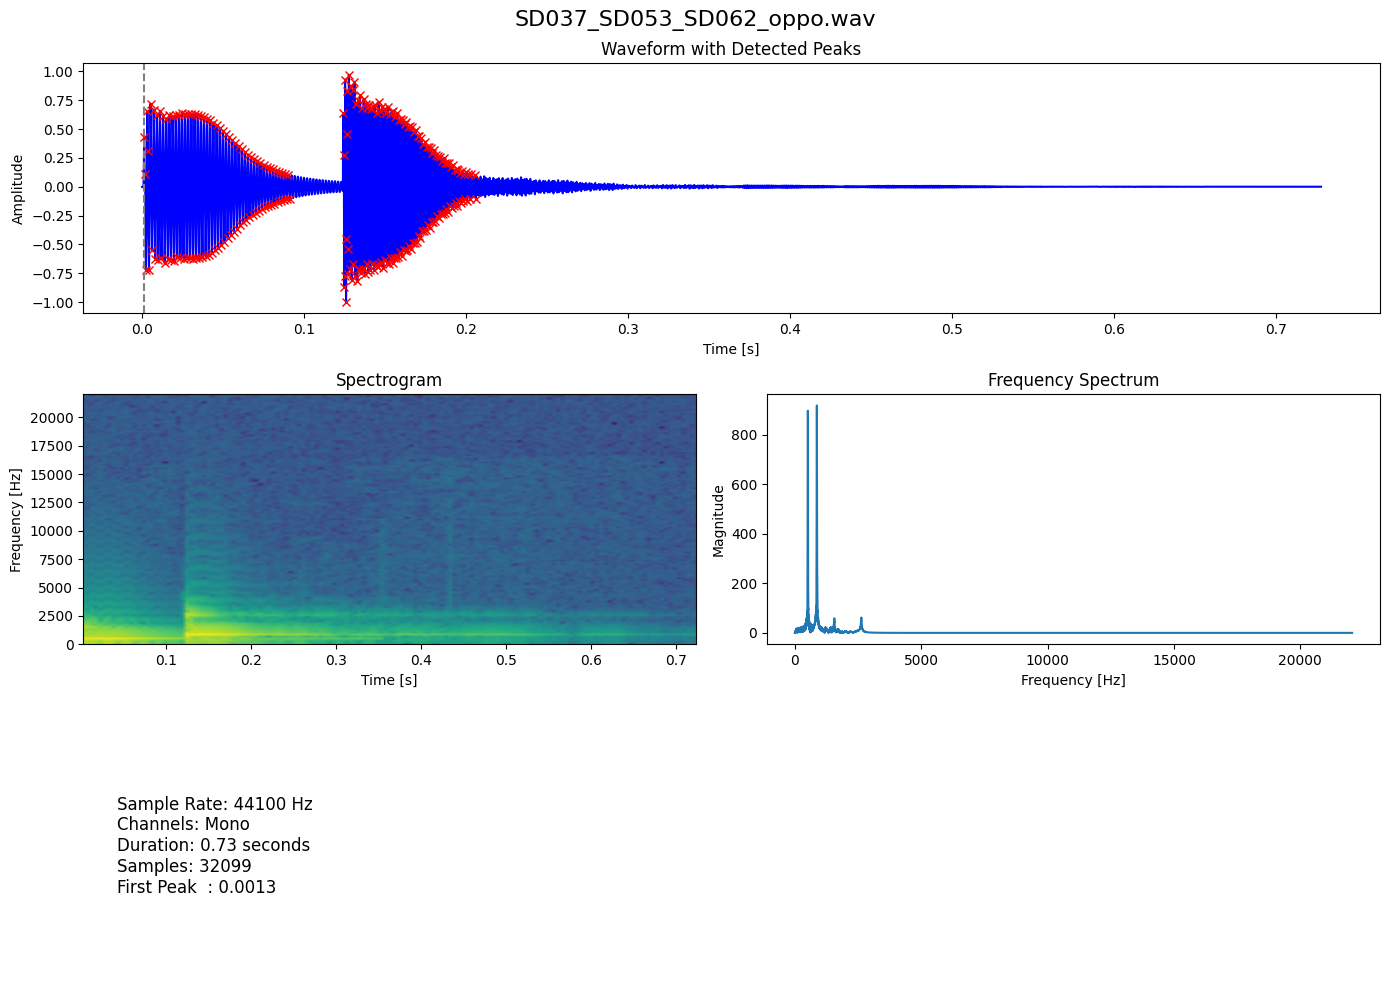

SD039_SD040_oppo_joy.wav


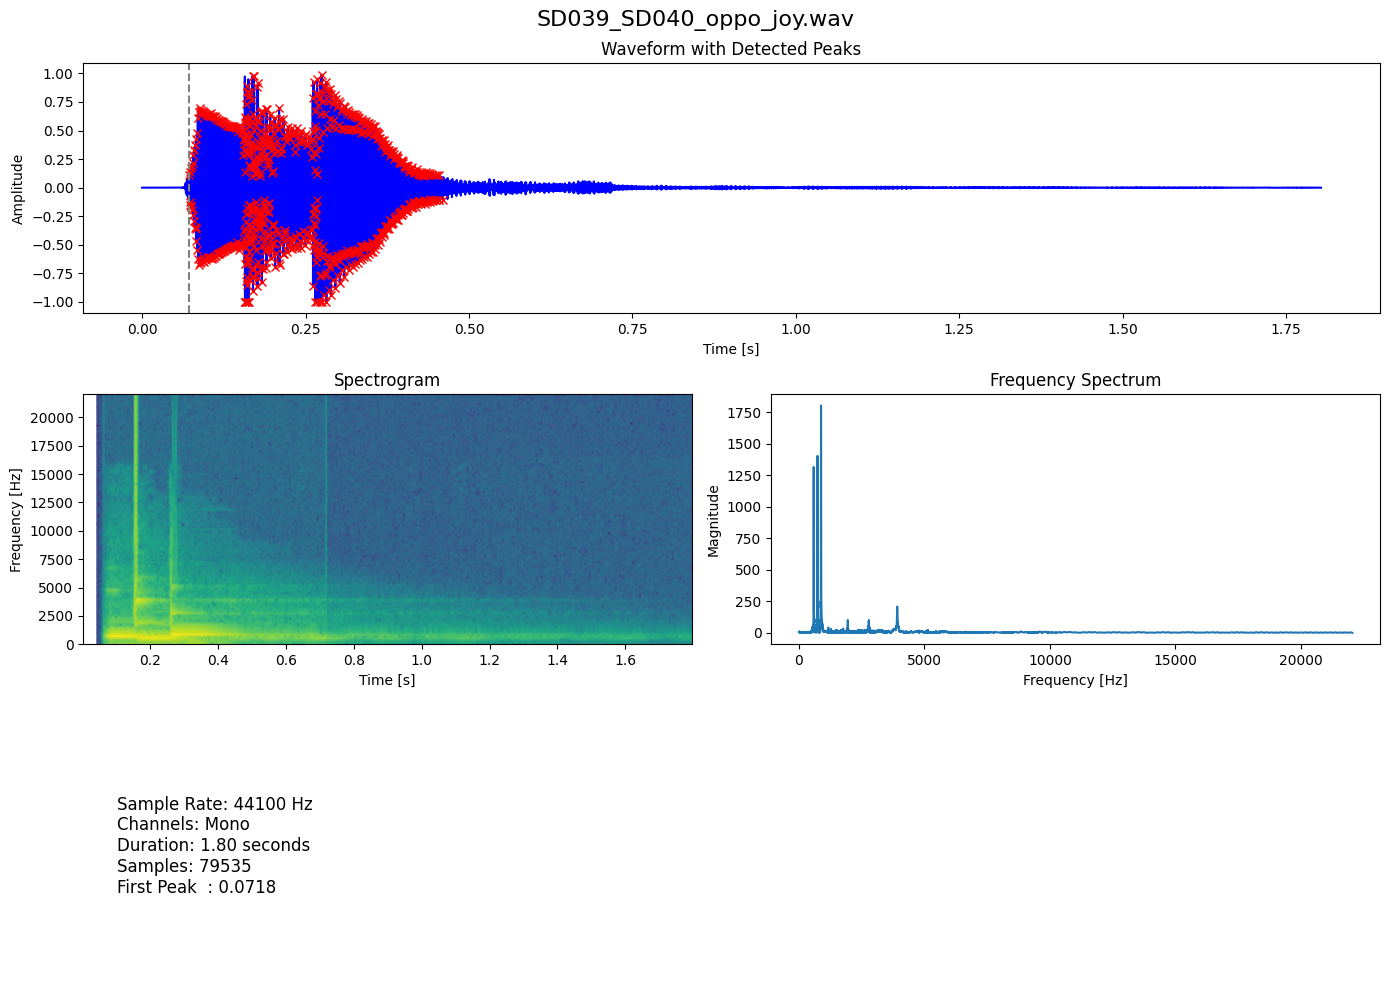

SD057_jai_shree_shyam.wav


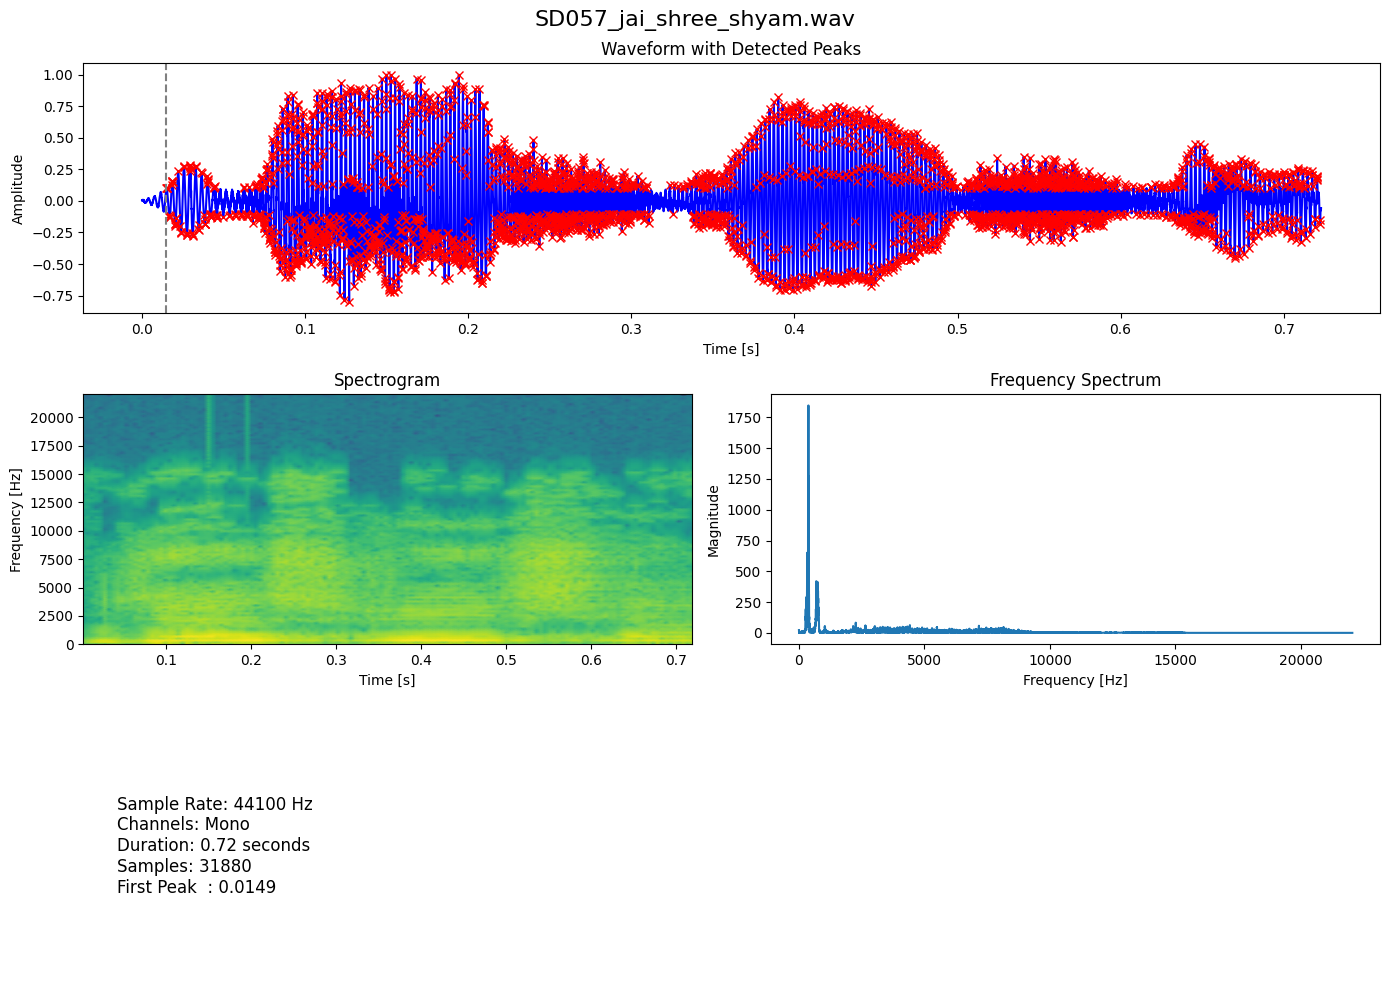

SD058_andes_vivo.wav


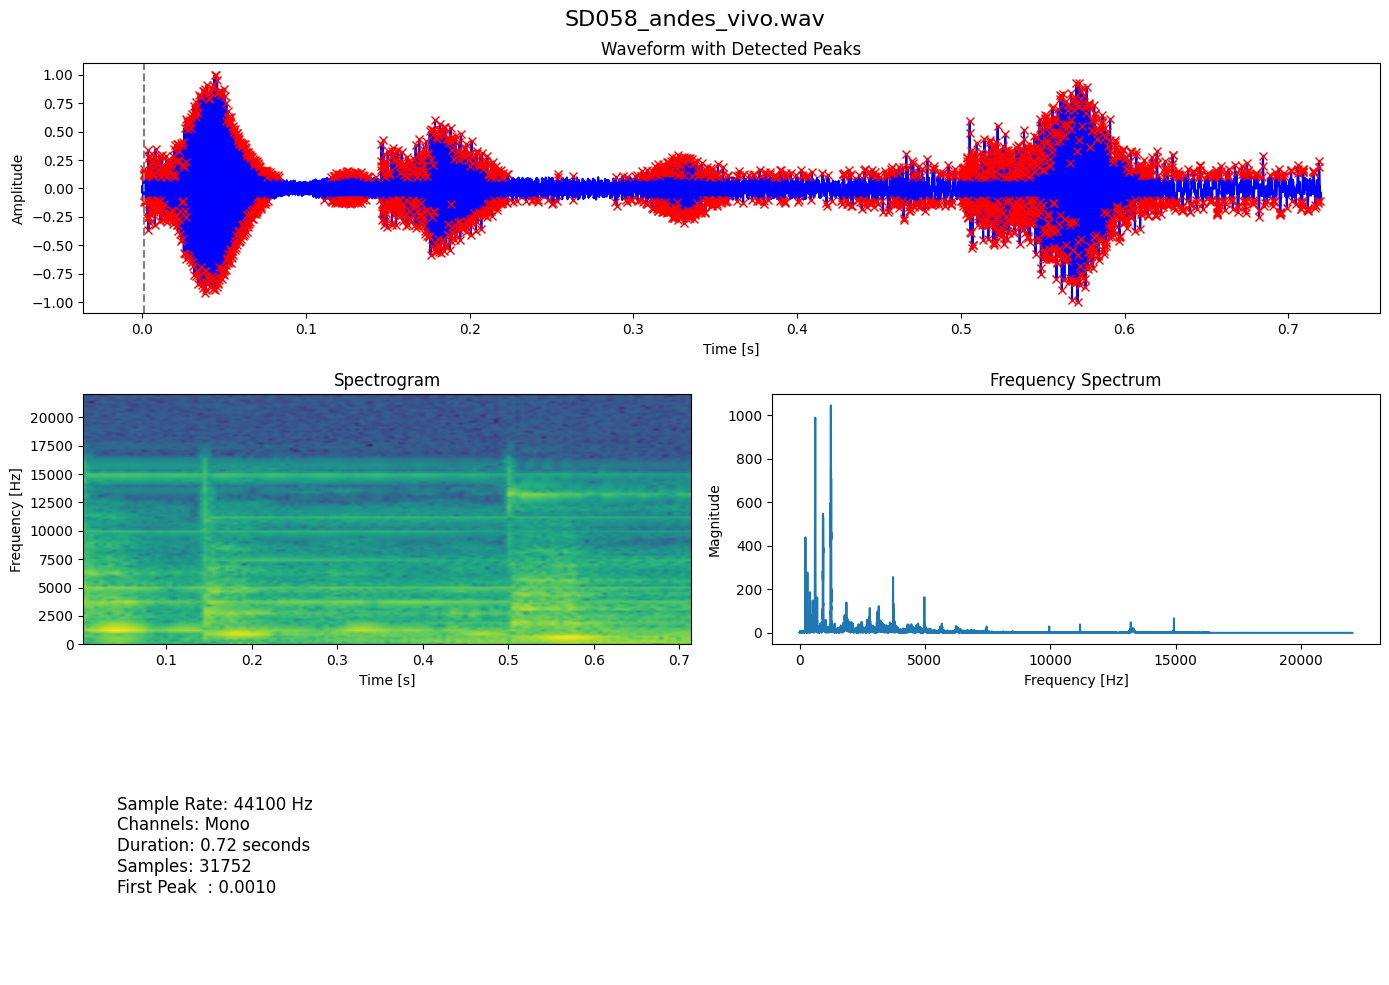

SD060_skyline_samsung.wav


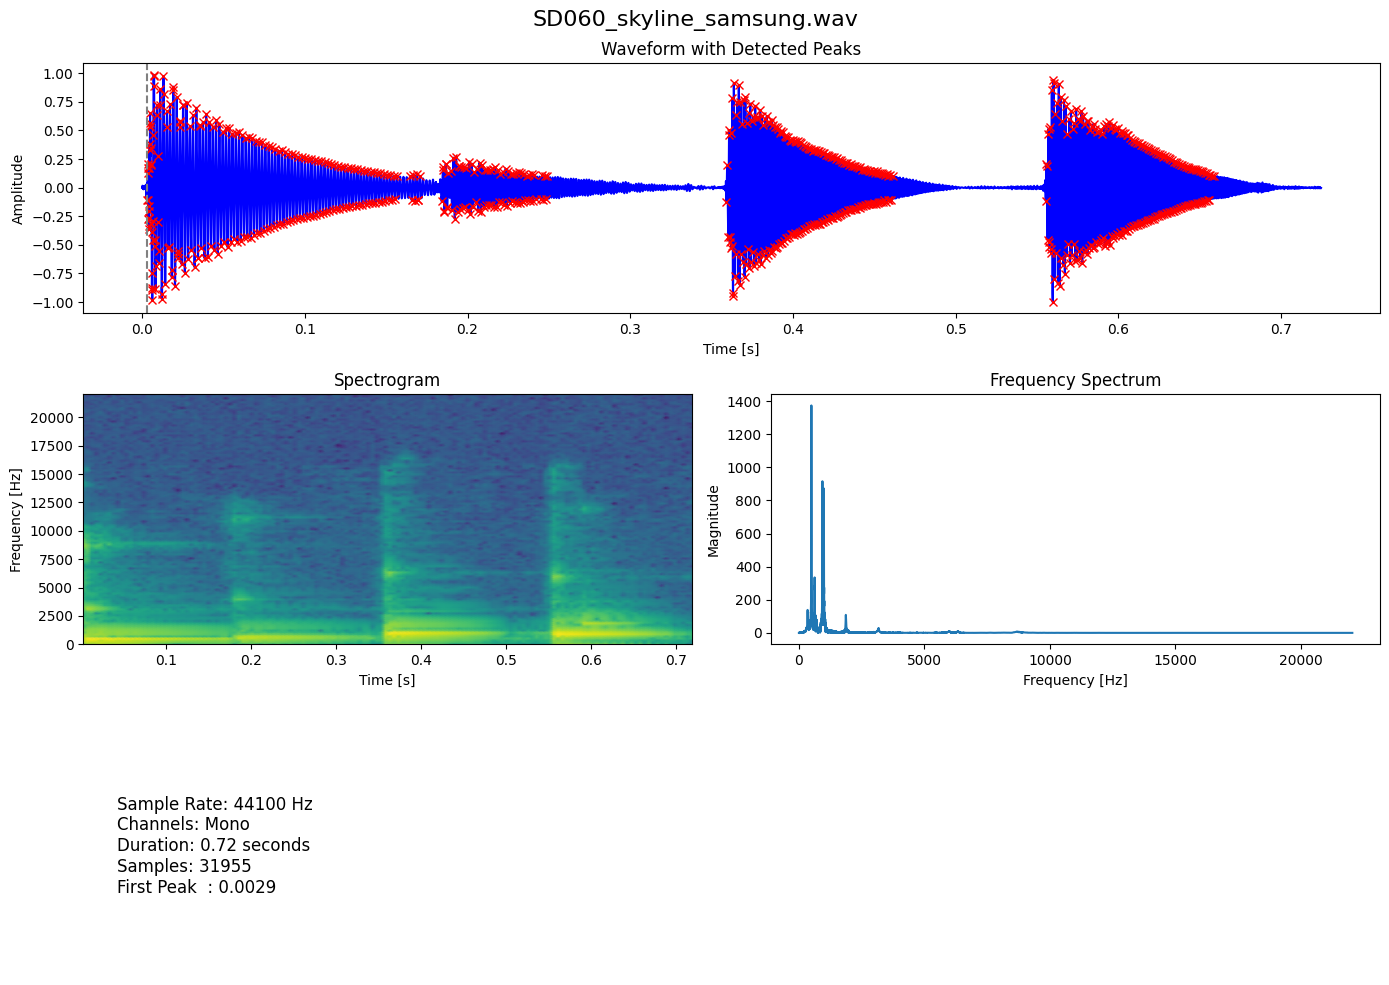

SD066_chime_moto.wav


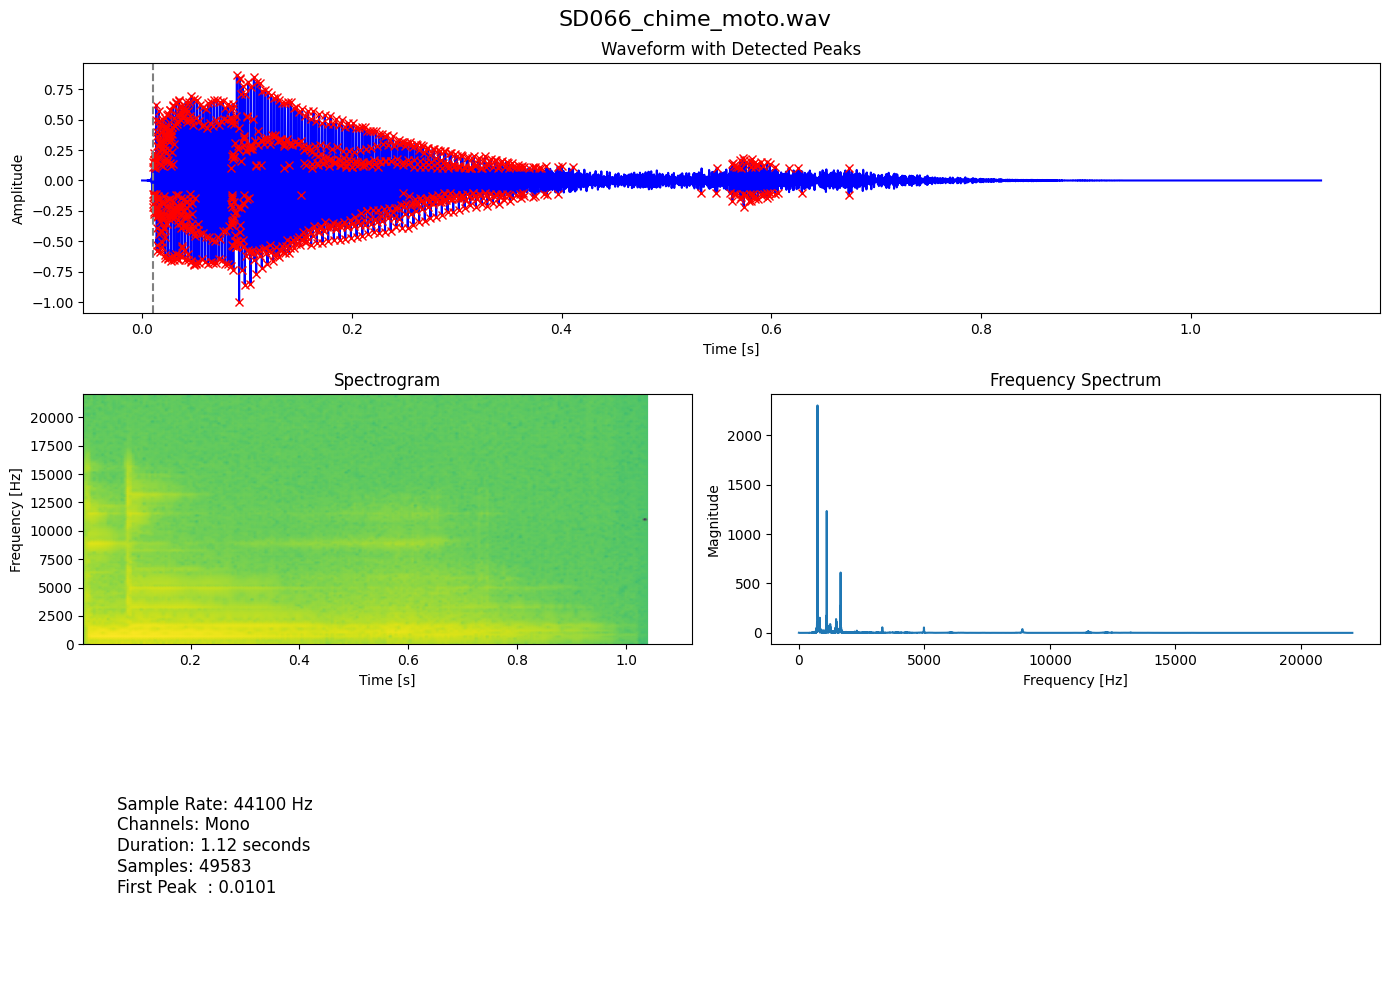

sub004_SD017_SD026_SD046_SD047_SD054__SD063_spaceline.wav


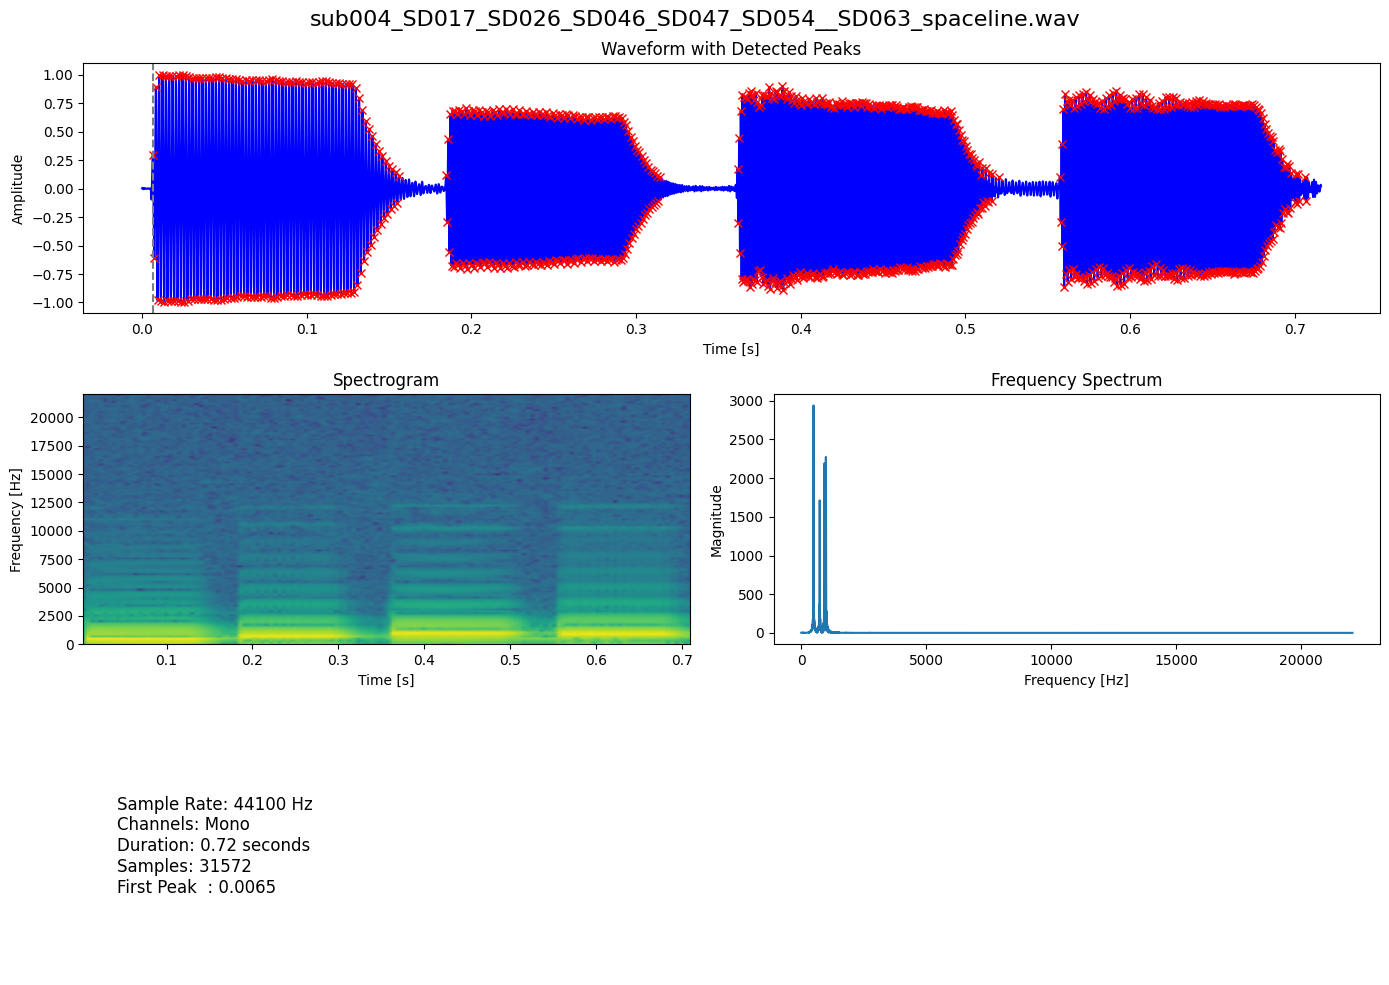

sub011_SD013_SD018_SD048_SD056_Sd061_SD064_Hello_inMoto.wav


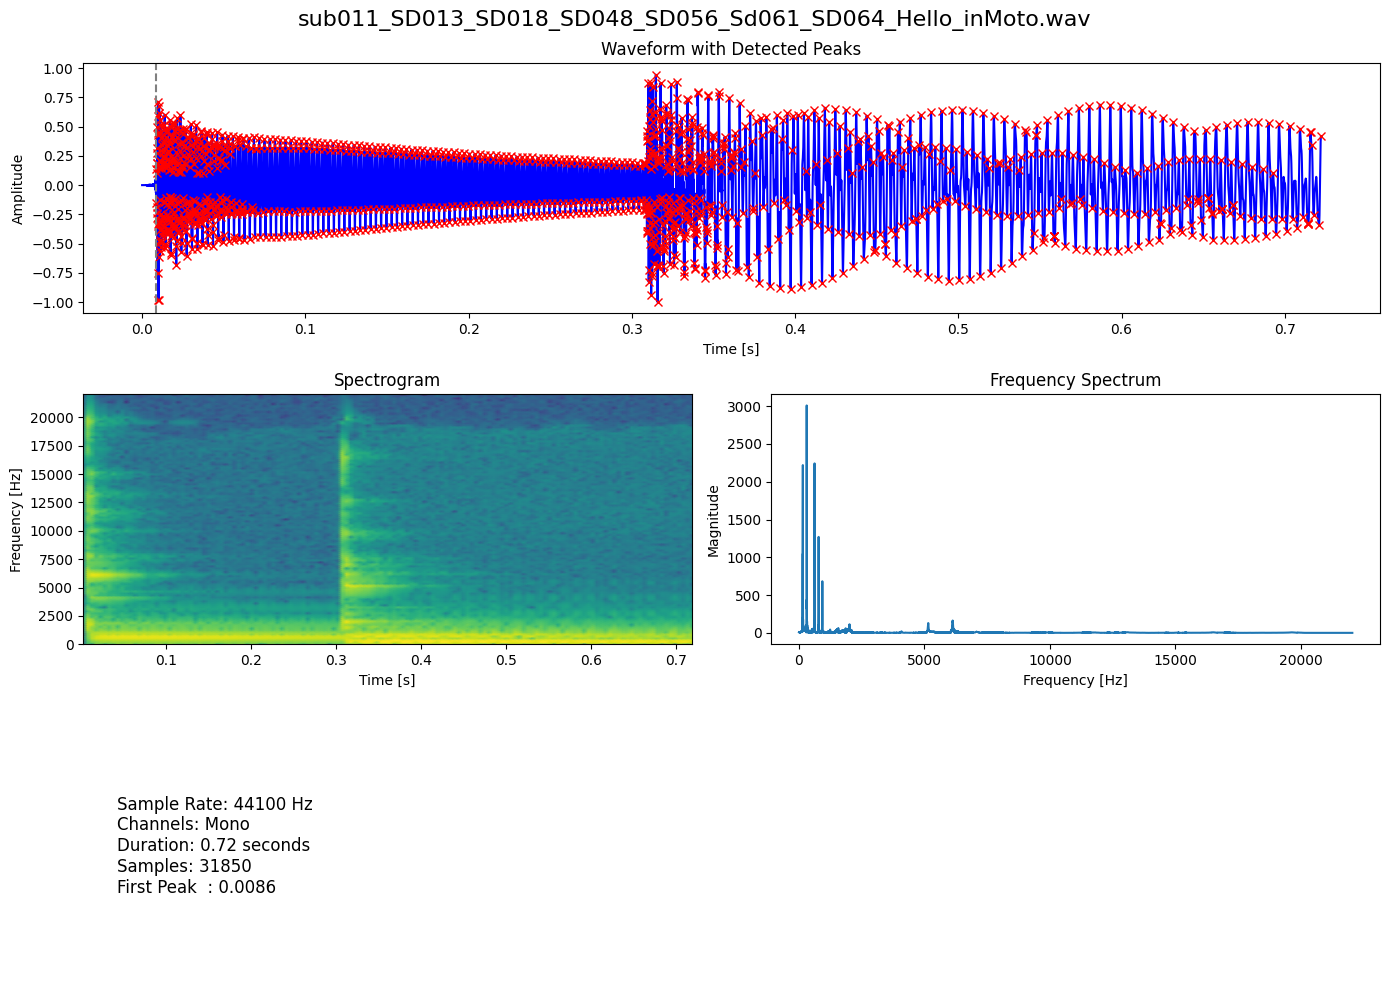

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from scipy.fft import fft, fftfreq
from scipy.signal import spectrogram, find_peaks
import os 
from pydub import AudioSegment
audio_folder = r'E:\ecf-exp2-notif-mmn\data\Processed\audio'

sub_peak = {}
for audio_ in os.listdir(audio_folder):
    # Load the .wav file
    print(audio_)
    try:
        rate, data = wav.read(os.path.join(audio_folder, audio_))
    except ValueError as e:
        if "nAvgBytesPerSec" in str(e):
            print(f"{audio_} has header error, using pydub to fix it...")
            # Recover using pydub
            audio = AudioSegment.from_wav(os.path.join(audio_folder, audio_))
            rate = audio.frame_rate
            data = np.array(audio.get_array_of_samples())
            if audio.channels == 2:
                data = data.reshape((-1, 2))
                data = data[:, 0]
        else:
            print(f"Skipping {audio_}: {e}")
            continue
    except Exception as e:
        print(f"Skipping {audio_}: {e}")
        continue
    if data.ndim > 1:
        data = data[:, 0]  # use first channel if stereo

    # Normalize
    data = data / np.max(np.abs(data))
    duration = len(data) / rate
    time = np.linspace(0, duration, len(data))
    # === Find peaks ===
    peaks, _ = find_peaks(np.abs(data), height=0.1)  # threshold = 10% of max
    first_peak_time = peaks[0] / rate if len(peaks) > 0 else None
    sub_peak[audio_] = first_peak_time
    # FFT
    N = len(data)
    yf = fft(data)
    xf = fftfreq(N, 1 / rate)[:N//2]

    # Spectrogram
    f, t, Sxx = spectrogram(data, fs=rate)

    # Plot all in one figure
    plt.figure(figsize=(14, 10))
    plt.suptitle(audio_, fontsize=16)
    # 1. Waveform
    plt.subplot(3, 1, 1)
    plt.plot(time, data, color='blue')
    plt.plot(time[peaks], data[peaks], "rx", label="Peaks")
    if len(peaks) > 0:
        plt.axvline(time[peaks[0]], color="gray", linestyle="--", label="First Peak")
    plt.title('Waveform with Detected Peaks')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')

    # 2. Spectrogram
    plt.subplot(3, 2, 3)
    plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    plt.title('Spectrogram')
    plt.xlabel('Time [s]')
    plt.ylabel('Frequency [Hz]')

    # 3. Frequency Spectrum
    plt.subplot(3, 2, 4)
    plt.plot(xf, np.abs(yf[:N//2]))
    plt.title('Frequency Spectrum')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude')

    # 4. Stats
    plt.subplot(3, 1, 3)
    plt.axis('off')
    stats = f"""
    Sample Rate: {rate} Hz
    Channels: {'Stereo' if data.ndim > 1 else 'Mono'}
    Duration: {duration:.2f} seconds
    Samples: {len(data)}
    First Peak  : {first_peak_time:.4f}
     """
    plt.text(0.01, 0.8, stats, fontsize=12, verticalalignment='top')

    plt.tight_layout()
    plt.show()


In [14]:
delayed_tune =[]
regu_tone = []
outliar_tone =[] 
def SD_sub(text):
    subs= []
    ls = text.split("_")
    for s in ls:
        if "SD" in s:
            subs.append(s.replace("SD","sub-sd"))
    return subs
for audio in sub_peak:
    if sub_peak[audio] > .026 and sub_peak[audio] < .07:
       delayed_tune.extend(SD_sub(audio))   
    elif sub_peak[audio] > .07: 
        outliar_tone.extend(SD_sub(audio))
    else: 
        regu_tone.extend(SD_sub(audio))
print(sorted(delayed_tune))
print(sorted(regu_tone))
print(sorted(outliar_tone))

['sub-sd012', 'sub-sd014', 'sub-sd016', 'sub-sd020', 'sub-sd027', 'sub-sd032', 'sub-sd033', 'sub-sd036', 'sub-sd038', 'sub-sd044', 'sub-sd051', 'sub-sd055', 'sub-sd67']
['sub-sd013', 'sub-sd015', 'sub-sd017', 'sub-sd018', 'sub-sd019', 'sub-sd021', 'sub-sd022', 'sub-sd023', 'sub-sd024', 'sub-sd025', 'sub-sd026', 'sub-sd028', 'sub-sd029', 'sub-sd030', 'sub-sd031', 'sub-sd035', 'sub-sd037', 'sub-sd041', 'sub-sd042', 'sub-sd043', 'sub-sd045', 'sub-sd046', 'sub-sd047', 'sub-sd048', 'sub-sd049', 'sub-sd052', 'sub-sd053', 'sub-sd054', 'sub-sd056', 'sub-sd057', 'sub-sd058', 'sub-sd060', 'sub-sd062', 'sub-sd063', 'sub-sd064', 'sub-sd065', 'sub-sd066']
['sub-sd034', 'sub-sd039', 'sub-sd040', 'sub-sd050', 'sub-sd059']


In [10]:
outliar_tone.extend(delayed_tune)
outliar_tone.extend(regu_tone)
print(len(outliar_tone))

55


In [11]:
print(sorted(outliar_tone))

['sub-sd012', 'sub-sd013', 'sub-sd014', 'sub-sd015', 'sub-sd016', 'sub-sd017', 'sub-sd018', 'sub-sd019', 'sub-sd020', 'sub-sd021', 'sub-sd022', 'sub-sd023', 'sub-sd024', 'sub-sd025', 'sub-sd026', 'sub-sd027', 'sub-sd028', 'sub-sd029', 'sub-sd030', 'sub-sd031', 'sub-sd032', 'sub-sd033', 'sub-sd034', 'sub-sd035', 'sub-sd036', 'sub-sd037', 'sub-sd038', 'sub-sd039', 'sub-sd040', 'sub-sd041', 'sub-sd042', 'sub-sd043', 'sub-sd044', 'sub-sd045', 'sub-sd046', 'sub-sd047', 'sub-sd048', 'sub-sd049', 'sub-sd050', 'sub-sd051', 'sub-sd052', 'sub-sd053', 'sub-sd054', 'sub-sd055', 'sub-sd056', 'sub-sd057', 'sub-sd058', 'sub-sd059', 'sub-sd060', 'sub-sd062', 'sub-sd063', 'sub-sd064', 'sub-sd065', 'sub-sd066', 'sub-sd67']


In [12]:
a = [v for k,v in sub_peak.items() if "SD" in k]
sum(a)/len(a) 
53,37,62

(53, 37, 62)

In [13]:


SD_sub('SD012_SD016_SD036_SD038_SD051_SD67_Whoop_doop.wav')


['sub-sd012', 'sub-sd016', 'sub-sd036', 'sub-sd038', 'sub-sd051', 'sub-sd67']